<a href="https://colab.research.google.com/github/robertmadril15/CS4410/blob/main/Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Samples shape: (569, 30)
Targets shape: (569,)

Training set size (398, 30) (398,)
Testing set size: (171, 30) (171,)

Estimator method score: 0.9298245614035088

Classification report:

              precision    recall  f1-score   support

   malignant       0.95      0.86      0.90        64
      benign       0.92      0.97      0.95       107

    accuracy                           0.93       171
   macro avg       0.93      0.92      0.92       171
weighted avg       0.93      0.93      0.93       171



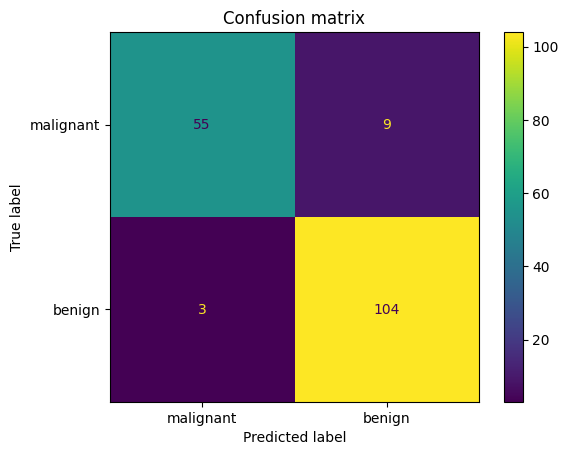

In [7]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

#load dataset
breast_cancer = load_breast_cancer()

#check sample and target size
print("Samples shape:", breast_cancer.data.shape)
print("Targets shape:", breast_cancer.target.shape)
print()

#split data
X_train, X_test, y_train, y_test = train_test_split(
    breast_cancer.data,
    breast_cancer.target,
    test_size=0.30,
    random_state=11,
    stratify=breast_cancer.target
)

#train and test set sizes
print("Training set size", X_train.shape, y_train.shape)
print("Testing set size:", X_test.shape, y_test.shape)
print()

#create model
nb = GaussianNB()

#train model
nb.fit(X_train, y_train)

#predicting
y_pred = nb.predict(X_test)

#estimator method score
print("Estimator method score:", nb.score(X_test, y_test))
print()

#confusion matrix
cm = confusion_matrix(y_test, y_pred)

#classification report
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=breast_cancer.target_names))

#confusion matrix visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=breast_cancer.target_names)
disp.plot()
plt.title("Confusion matrix")
plt.show()

#k fold cross validation using cross_val_score
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

scores = cross_val_score(
    estimator=nb,
    X=breast_cancer.data,
    y=breast_cancer.target,
    cv=kfold
)

#running multiple models to find best one
estimators = {
    "GaussianNB": nb,
    "KNeighborsClassifier": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(solver="lbfgs", max_iter=10000),
    "SVC": SVC(gamma="scale")
}

